MULTI LINEAR REGRESSION


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df=pd.read_csv('economic_index.csv')

In [90]:
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [91]:
df.value_counts()

Unnamed: 0  year  month  interest_rate  unemployment_rate  index_price
0           2017  12     2.75           5.3                1464           1
1           2017  11     2.50           5.3                1394           1
2           2017  10     2.50           5.3                1357           1
3           2017  9      2.50           5.3                1293           1
4           2017  8      2.50           5.4                1256           1
5           2017  7      2.50           5.6                1254           1
6           2017  6      2.50           5.5                1234           1
7           2017  5      2.25           5.5                1195           1
8           2017  4      2.25           5.5                1159           1
9           2017  3      2.25           5.6                1167           1
10          2017  2      2.00           5.7                1130           1
11          2017  1      2.00           5.9                1075           1
12          2016 

In [92]:
df.drop(columns=['year','month'],axis=1,inplace=True)

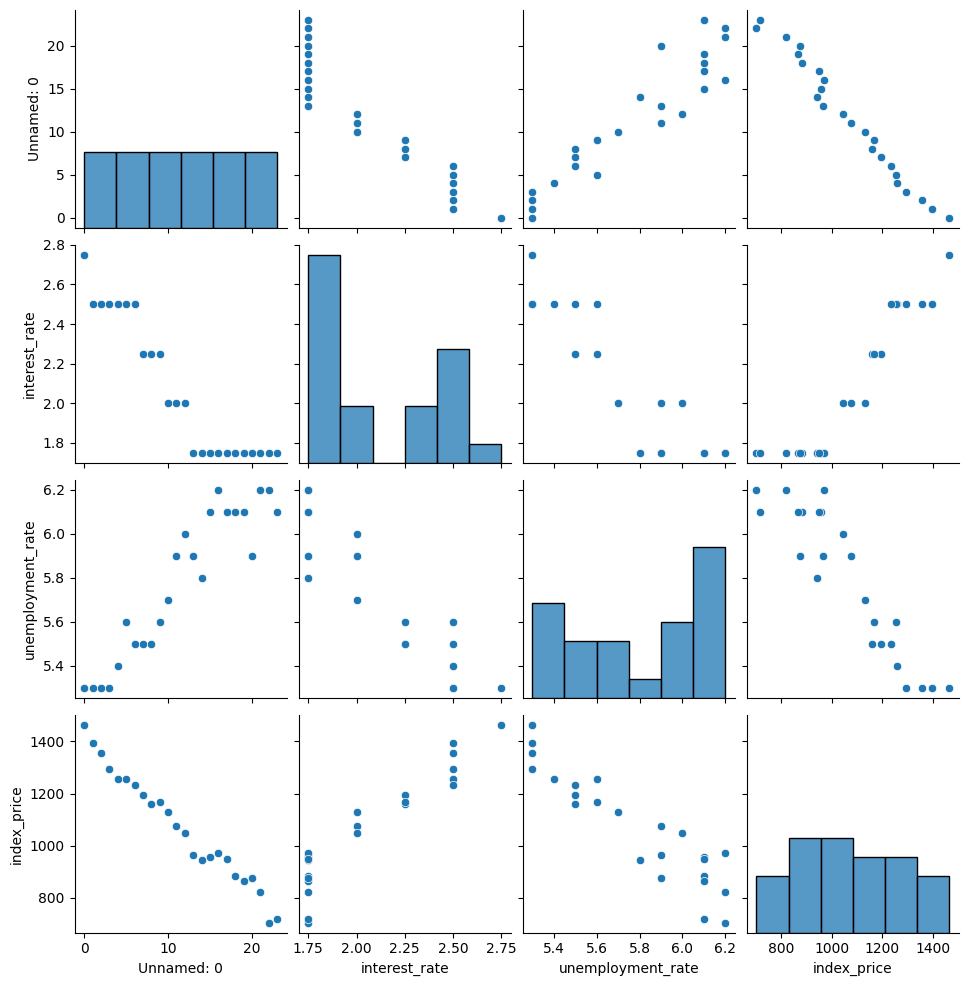

In [126]:
## now we will train our model on the basics of the current dataset
## first use visullization
sns.pairplot(df)

In [94]:
df.corr()
## here from the correlation we get that if 
## intrest rate is directly proportonal to index rate and inverseky to unemployement rate
## unemplyment rate is inversely to intrest rate and index price 
##index price is directly to intrest rate  and inversely to unemployment rate 

,Unnamed: 0,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-0.934555,0.935300,-0.988246
interest_rate,-0.934555,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-0.925814,1.000000,-0.922338
index_price,-0.988246,0.935793,-0.922338,1.000000


<Axes: xlabel='interest_rate', ylabel='index_price'>

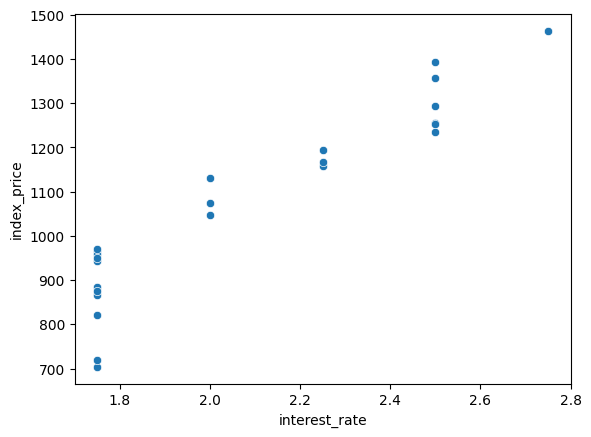

In [95]:
## visualizae more closely
sns.scatterplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

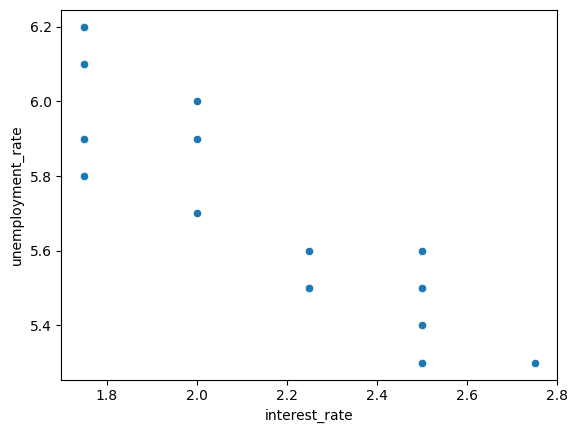

In [96]:
## now visualize other feature 
sns.scatterplot(x='interest_rate',y='unemployment_rate',data=df)

In [97]:
## independent and dependent featur 
X=df[['interest_rate','unemployment_rate']]
Y=df['index_price']

In [98]:
## train test split 
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

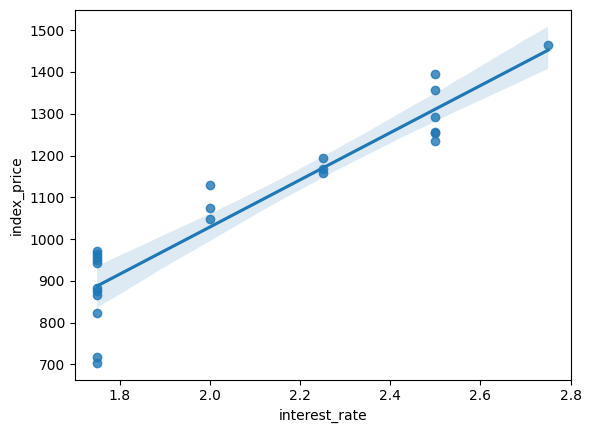

In [99]:
## we use one plot which gives us the best fit line 
sns.regplot(x='interest_rate', y='index_price', data=df)


<Axes: xlabel='unemployment_rate', ylabel='index_price'>

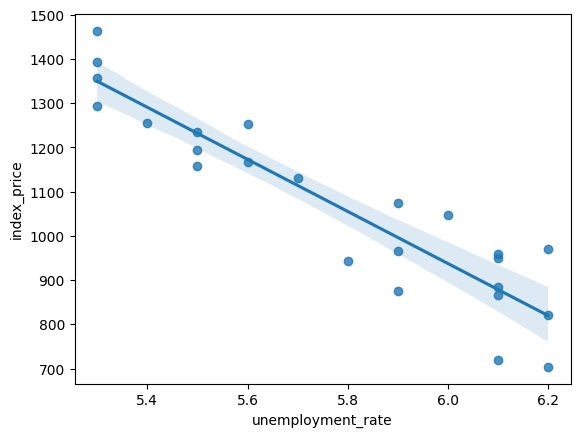

In [100]:
sns.regplot(x='unemployment_rate', y='index_price', data=df)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features
X = df[['interest_rate', 'unemployment_rate']]

# Fit and transform
X_train = scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)



In [102]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [103]:
X_test

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [104]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
print(regression.intercept_)
print(regression.coef_)


1053.4444444444443
[  88.27275507 -116.25716066]


In [ ]:
plt.plot(X_train,Y)

In [106]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,Y_train,cv=5,scoring='r2')
scores_mse = cross_val_score(regression, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')


In [107]:
print(" this is r2",validation_score)
print(" this is rmse",scores_mse)
## these values tell us how well my model perform on the given set of the data 

 this is r2 [0.96373611 0.68310264 0.80679599 0.79355092 0.96849166]
 this is rmse [-1861.74046551 -8715.8459466  -7707.52362191 -9169.13776461
  -791.32842311]


In [108]:
print(validation_score.mean()*100)
print(-(scores_mse.mean()))

84.31354650801491
5649.115244350756


In [ ]:
## PREDECTION
## This is my model 
y_pred=regression.predict(X_test)



In [110]:
## Performance metrix 
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [111]:
RME=mean_squared_error(Y_test,y_pred)
RAE=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(RME)

In [112]:
print(" RME IS", RME)
print("RAE is",RAE)
print("RMSE",rmse)

 RME IS 8108.567426306604
RAE is 73.80444932337097
RMSE 90.04758423359621


In [113]:
## now calculating the R2
from sklearn.metrics import r2_score


In [114]:
score=r2_score(Y_test, y_pred)

In [115]:
print(score*100)

75.91371539010257


ASSUMPTIONS

In [ ]:
residuals=Y_test-y_pred
print(residuals)
## these are the errors 


8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


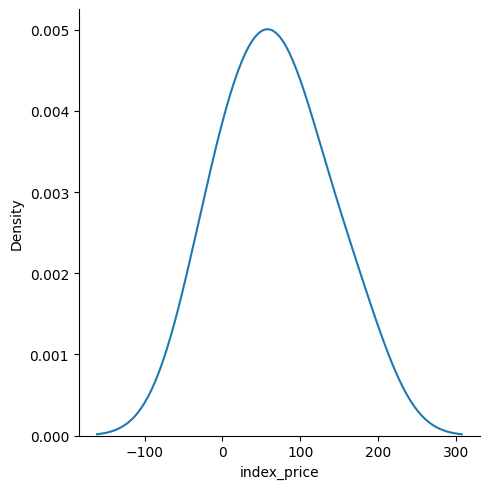

In [117]:
## plot the residuals 
sns.displot(residuals,kind='kde')

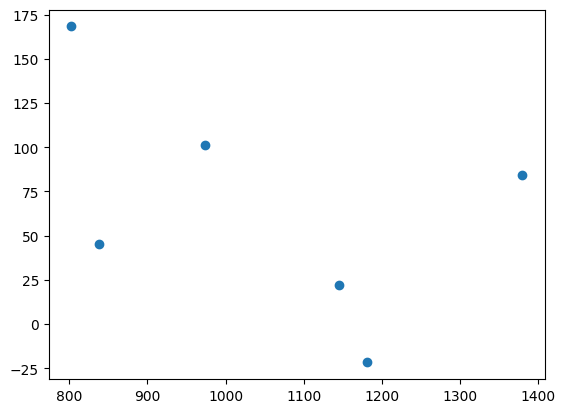

In [118]:
## scatter plot with respect to prediction and residuals 
plt.scatter(y_pred,residuals)

In [132]:
# new value (example)
## now we are giving the values 
x_new = [[2,6]]   # always 2D

# prediction
y_new = regression.predict(x_new)

print("Predicted value:", y_new)

Predicted value: [532.44699062]
